# Online Sales Data Analysis

## ABOUT DATA

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\data_analyst\\Portfolio\\data\\online_retail_II.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


#### Insights:
- 8 column
- 1.067.371 rows
- file size is 65.1 MB
- has missing value

## Missing Values

In [28]:
df.isnull().sum().sort_values(ascending=False)

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

#### Insights:
 The dataset has 2 columns with a significant number of missing values: 'Description' and 'Customer ID'. 
 
 - The 'Description' column has 1454 missing values
 - The 'Customer ID' column has 135080 missing values
 
 This suggests that a large portion of the data is incomplete, which may affect the analysis and insights derived from the dataset.

 ### Fill the missing values in the 'Description' Column with 'unknown'

In [29]:
df['Description'] = df['Description'].fillna('Unknown')

## PRODUCT ANALYSIS

### 1. 💰 Create Revenue Metric

In [30]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['TotalPrice'].sum()

np.float64(19287250.568)

In [31]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice'],
      dtype='str')

### 🏆 2. Top Products by Revenue

In [32]:
df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS                           84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: TotalPrice, dtype: float64

📦 3. Top Products by Quantity

In [33]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

In [34]:
# Create revenue rank metric
revenue_rank = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_rank['Revenue_Rank'] = revenue_rank.index + 1

In [35]:
# Create quantity rank metric
qty_rank = (
    df.groupby('Description')['Quantity']   
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

qty_rank['Qty_Rank'] = qty_rank.index + 1

In [36]:
#Merge the two rank dataframes
merged = pd.merge(revenue_rank, qty_rank, on='Description')

In [37]:
#top 10 products by revenue rank or quantity rank
top_10 = merged[(merged['Revenue_Rank'] <= 10) | (merged['Qty_Rank'] <= 10)]
top_10

,Description,TotalPrice,Revenue_Rank,Quantity,Qty_Rank
0,REGENCY CAKESTAND 3 TIER,327813.65,1,26126,41
1,DOTCOM POSTAGE,322647.47,2,1438,1668
2,WHITE HANGING HEART T-LIGHT HOLDER,257533.90,3,93050,2
3,JUMBO BAG RED RETROSPOT,148800.64,4,78090,4
4,PARTY BUNTING,147948.50,5,28110,35
5,ASSORTED COLOUR BIRD ORNAMENT,131413.85,6,81306,3
6,PAPER CHAIN KIT 50'S CHRISTMAS,121662.14,7,35985,22
7,POSTAGE,112341.00,8,5158,516
8,CHILLI LIGHTS,84854.16,9,16702,99
9,ROTATING SILVER ANGELS T-LIGHT HLDR,73814.72,10,13775,136


In [38]:
#double top 10 products by revenue rank and quantity rank
double_top_10 = merged[(merged['Revenue_Rank'] <= 10) & (merged['Qty_Rank'] <= 10)]
double_top_10

,Description,TotalPrice,Revenue_Rank,Quantity,Qty_Rank
2,WHITE HANGING HEART T-LIGHT HOLDER,257533.90,3,93050,2
3,JUMBO BAG RED RETROSPOT,148800.64,4,78090,4
5,ASSORTED COLOUR BIRD ORNAMENT,131413.85,6,81306,3


#### Key Insights — Product Performance Analysis
- Revenue and quantity do not always align. Some products that rank high in quantity sold are not necessarily the highest in revenue, indicating differences in pricing and product value contribution.
- The product “PAPER CHAIN KIT 50'S CHRISTMAS” ranks 7th in revenue but 22nd in quantity sold, suggesting that certain products generate strong revenue despite lower sales volume.
- High-volume products tend to contribute consistently to sales activity, but they may not always be the most profitable items per unit sold.
- Revenue is concentrated in a small number of top-performing products, indicating a potential Pareto distribution (80/20 effect) in product sales performance.
- There is a clear distinction between product popularity (quantity sold) and product profitability (revenue contribution), highlighting the importance of analyzing both metrics together for better business decisions.
- If cost or margin data were available, a deeper analysis could identify true profitability and help optimize product strategy beyond just revenue and demand.

### 4. 📈 Monthly Revenue Trend

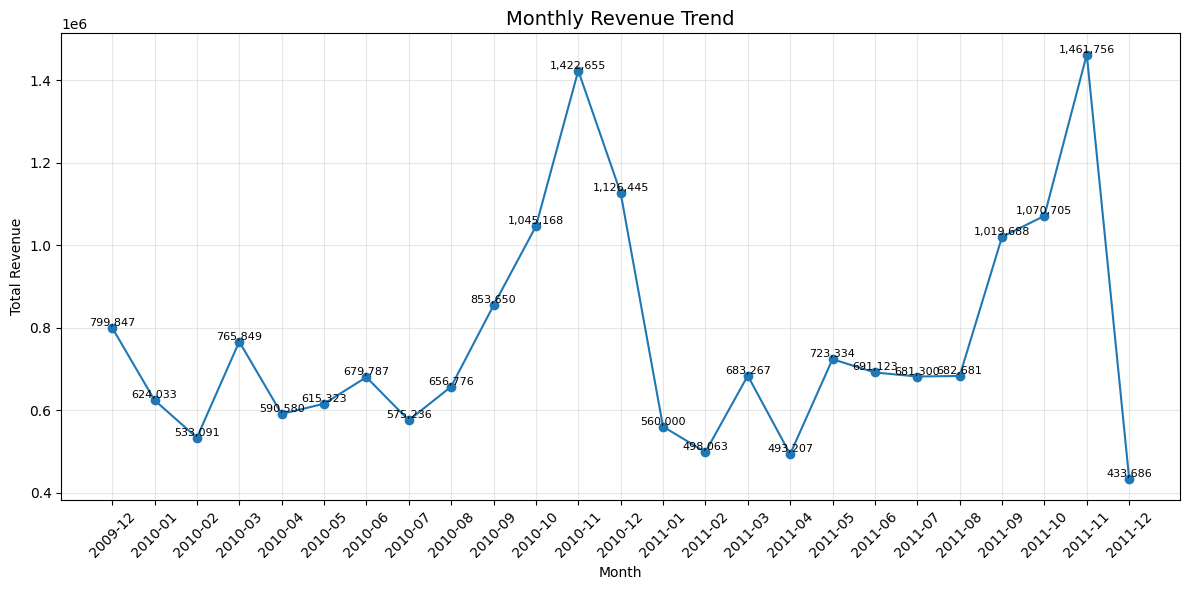

In [47]:
# datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()

# plot
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], marker='o')

# kasih label di setiap titik
for x, y in zip(monthly_revenue['Month'], monthly_revenue['TotalPrice']):
    ax.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

# styling biar enak dilihat
plt.xticks(rotation=45)
ax.set_title("Monthly Revenue Trend", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Insights:
- Monthly revenue shows a consistent year-over-year growth trend, indicating overall business expansion and increasing demand over time.
- Strong seasonality is observed in sales performance, with revenue consistently peaking between July and January each year.This period represents the primary sales cycle and likely accounts for a significant portion of annual revenue.
- Early months of the year generally show lower revenue, highlighting a recurring cyclical pattern in customer purchasing behavior.
- These patterns suggest that strategic planning in inventory management, marketing campaigns, and promotions should be prioritized ahead of peak months to maximize revenue performance.

### 5. 🌍 Revenue by Country

In [ ]:
# how many unique countries
df['Country'].nunique()

In [50]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)  

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: TotalPrice, dtype: float64

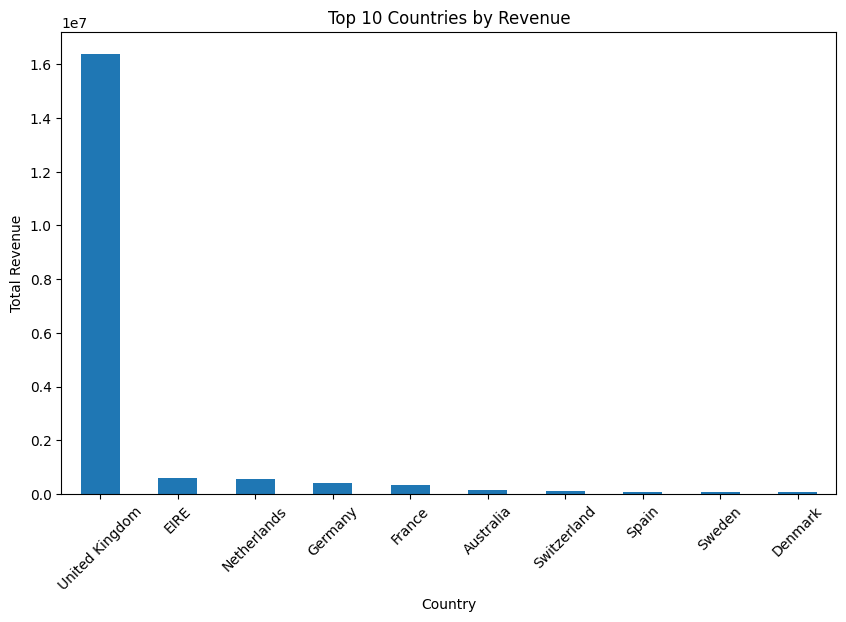

In [53]:
# plot top 10 countries by revenue
import matplotlib.pyplot as plt

top_10_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

#### Insight 

The majority of revenue comes from the United Kingdom, which is expected as the retail store is based in the UK. This indicates strong domestic market dominance.

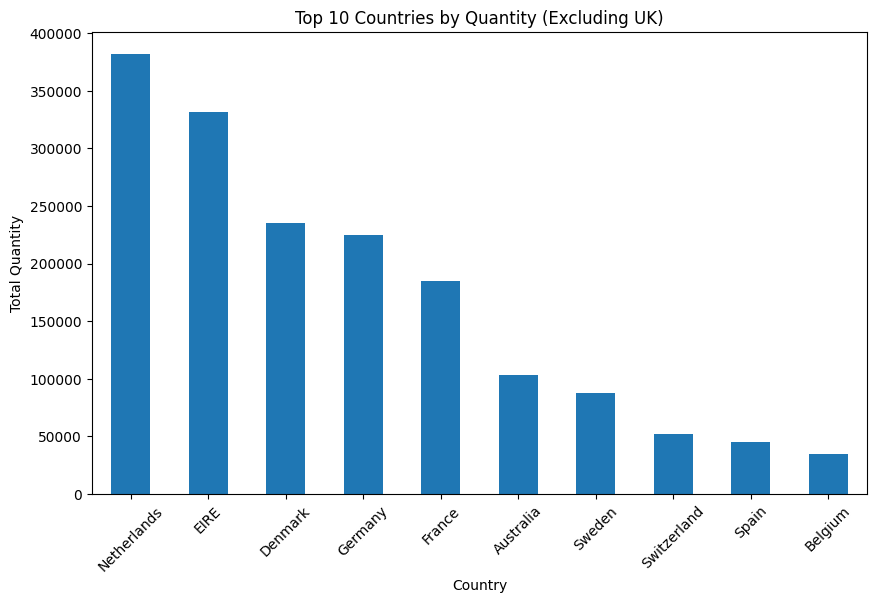

In [54]:
#plot top 10 countries by quantity exclude United Kingdom
top_10_countries_qty = df[df['Country'] != 'United Kingdom'].groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6)) 
top_10_countries_qty.plot(kind='bar')
plt.title('Top 10 Countries by Quantity (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.show()

#### Insights:
- When excluding the UK from the analysis, revenue distribution changes significantly, with the Netherlands and the Republic of Ireland (EIRE) emerging as the top-performing international markets.
- This suggests that while the UK drives the core revenue base, there is also meaningful demand in select European markets, particularly in the Netherlands and Ireland.
- The findings highlight the importance of both maintaining strong domestic performance and exploring targeted growth opportunities in high-performing international regions.


1. Revenue definition

→ TotalPrice

2. What makes money

→ Top products by revenue

3. What is popular

→ Quantity analysis

4. When money comes

→ Monthly trend

5. Where money comes from

→ Country analysis



#CUSTOMER ANALYSIS